<div style="background: linear-gradient(135deg,#0f2027,#203a43,#2c5364); padding:30px; border-radius:15px; color:white; font-family:Arial;">

<h1 style="text-align:center; color:#00E5FF;">💳 Loan Approval Prediction</h1>

<h3 style="text-align:center; color:#FFD54F;">
AI-Powered Loan Decision System
</h3>

<hr style="border:2px solid #00E5FF;">

<h2 style="color:#FFD54F;"> Overview</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
This project addresses one of the most critical challenges in the <strong>banking and financial sector</strong> 
evaluating loan applications efficiently and accurately.
</p>

<p style="color:#FF6B6B;">
Traditional manual processes are <strong>slow, inconsistent, and prone to human bias</strong>.
This project builds an <strong>automated ML pipeline</strong> to predict whether a loan should be 
<strong>approved or rejected</strong> based on applicant data.
</p>

<hr style="border:1px dashed #FFD54F;">

<h2 style="color:#FFD54F;"> Project Objective</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
The goal is to train a <strong>binary classification model</strong> using features such as:
</p>

<ul style="line-height:1.8;">
<li> Annual Income</li>
<li> Credit Score</li>
<li> Total Assets</li>
<li> Loan Amount</li>
<li> Employment Information</li>
</ul>

<p style="color:#FF6B6B;">
The model supports <strong>faster, fairer, and data-driven lending decisions</strong>.
</p>

<hr style="border:1px dashed #FFD54F;">

<h2 style="color:#FFD54F;"> Business Impact</h2>

<ul style="line-height:1.8;">
<li> Identify <strong>low-risk applicants</strong> for approval</li>
<li> Flag <strong>high-risk applicants</strong></li>
<li> Reduce manual review time</li>
<li> Minimize human error</li>
<li> Ensure consistent decision criteria</li>
</ul>

<hr style="border:1px dashed #FFD54F;">

<h2 style="color:#FFD54F;"> Algorithms Used</h2>

<div style="background:#1e293b; padding:20px; border-radius:10px;">

<ul style="line-height:1.8; color:#8BE9FD;">

<li> <strong>Logistic Regression</strong> - baseline linear model</li>
<li> <strong>Decision Tree</strong> - captures non-linear patterns</li>
<li> <strong>Random Forest</strong> - reduces variance using ensemble learning</li>
<li> <strong>Gradient Boosting</strong> - sequential learning with highest performance</li>

</ul>

<p style="color:#B2FF59;">
<strong>Gradient Boosting</strong> achieved the best performance and was selected as the final model.
</p>

</div>

<hr style="border:1px dashed #FFD54F;">

<h2 style="color:#FFD54F;"> Dataset</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
The dataset contains <strong>4,269 loan applications</strong> with <strong>13 features</strong> 
covering demographic and financial information.
</p>

<p style="color:#FF6B6B;">
Target variable: <strong>Loan Status (Approved / Rejected)</strong>.
</p>

<hr style="border:1px dashed #FFD54F;">

<h2 style="color:#FFD54F;"> Results</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
The <strong>Gradient Boosting model</strong> achieved:
</p>

<p style="background:#263238; padding:15px; border-radius:10px; color:#00E676; font-size:18px; text-align:center;">
 Test Accuracy: <strong>98.5%</strong>
</p>

<p style="color:#FF6B6B;">
The model shows <strong>no significant overfitting</strong>, making it a reliable and 
<strong>production-ready solution</strong>.
</p>

</div>

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Install & Import Libraries
</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

PALETTE = ["#2EC4B6", "#E71D36", "#FF9F1C", "#4361EE", "#7209B7"]
sns.set_style("darkgrid")

print("All libraries imported successfully.")

All libraries imported successfully.


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Read Data
</h2>

In [2]:
df = pd.read_csv("/kaggle/input/datasets/architsharma01/loan-approval-prediction-dataset/loan_approval_dataset.csv")

df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Drop loan_id
</h2>

In [3]:
df.drop(columns=["loan_id"], inplace=True)

print("loan_id dropped. New shape:", df.shape)

loan_id dropped. New shape: (4269, 12)


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Basic Data Info
</h2>

In [4]:
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("STATISTICAL SUMMARY")
print("=" * 55)
df.describe().T

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Missing Values
</h2>

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent (%)": missing_pct
}).sort_values("Missing Percent (%)", ascending=False)

print(missing_df)

                          Missing Count  Missing Percent (%)
no_of_dependents                      0                  0.0
education                             0                  0.0
self_employed                         0                  0.0
income_annum                          0                  0.0
loan_amount                           0                  0.0
loan_term                             0                  0.0
cibil_score                           0                  0.0
residential_assets_value              0                  0.0
commercial_assets_value               0                  0.0
luxury_assets_value                   0                  0.0
bank_asset_value                      0                  0.0
loan_status                           0                  0.0


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Fix Negative Asset Values
</h2>

In [6]:
negative_assets = df[df["residential_assets_value"] < 0]
print(f"Rows with negative residential_assets_value: {len(negative_assets)}")

df = df[df["residential_assets_value"] >= 0]
print(f"Dataset shape after fix: {df.shape}")

Rows with negative residential_assets_value: 28
Dataset shape after fix: (4241, 12)


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Target Variable Distribution
</h2>

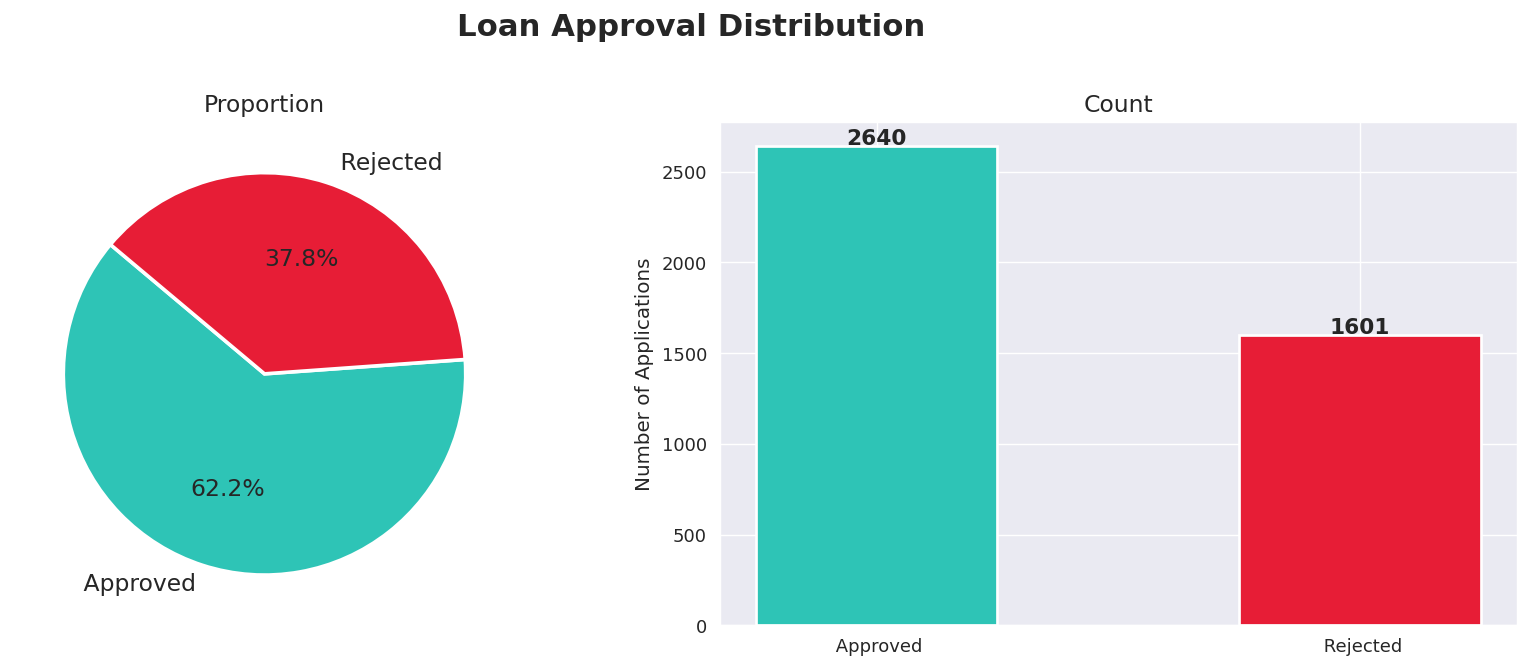

In [7]:
target_col = "loan_status"

counts = df[target_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Loan Approval Distribution", fontsize=17, fontweight="bold", y=1.02)

axes[0].pie(counts.values, labels=counts.index,
            colors=[PALETTE[0], PALETTE[1]],
            autopct="%1.1f%%", startangle=140,
            wedgeprops=dict(edgecolor="white", linewidth=2),
            textprops={"fontsize": 13})
axes[0].set_title("Proportion", fontsize=13)

axes[1].bar(counts.index, counts.values,
            color=[PALETTE[0], PALETTE[1]], edgecolor="white", linewidth=1.5, width=0.5)
axes[1].set_title("Count", fontsize=13)
axes[1].set_ylabel("Number of Applications", fontsize=11)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, str(v), ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Numerical Features Distribution
</h2>

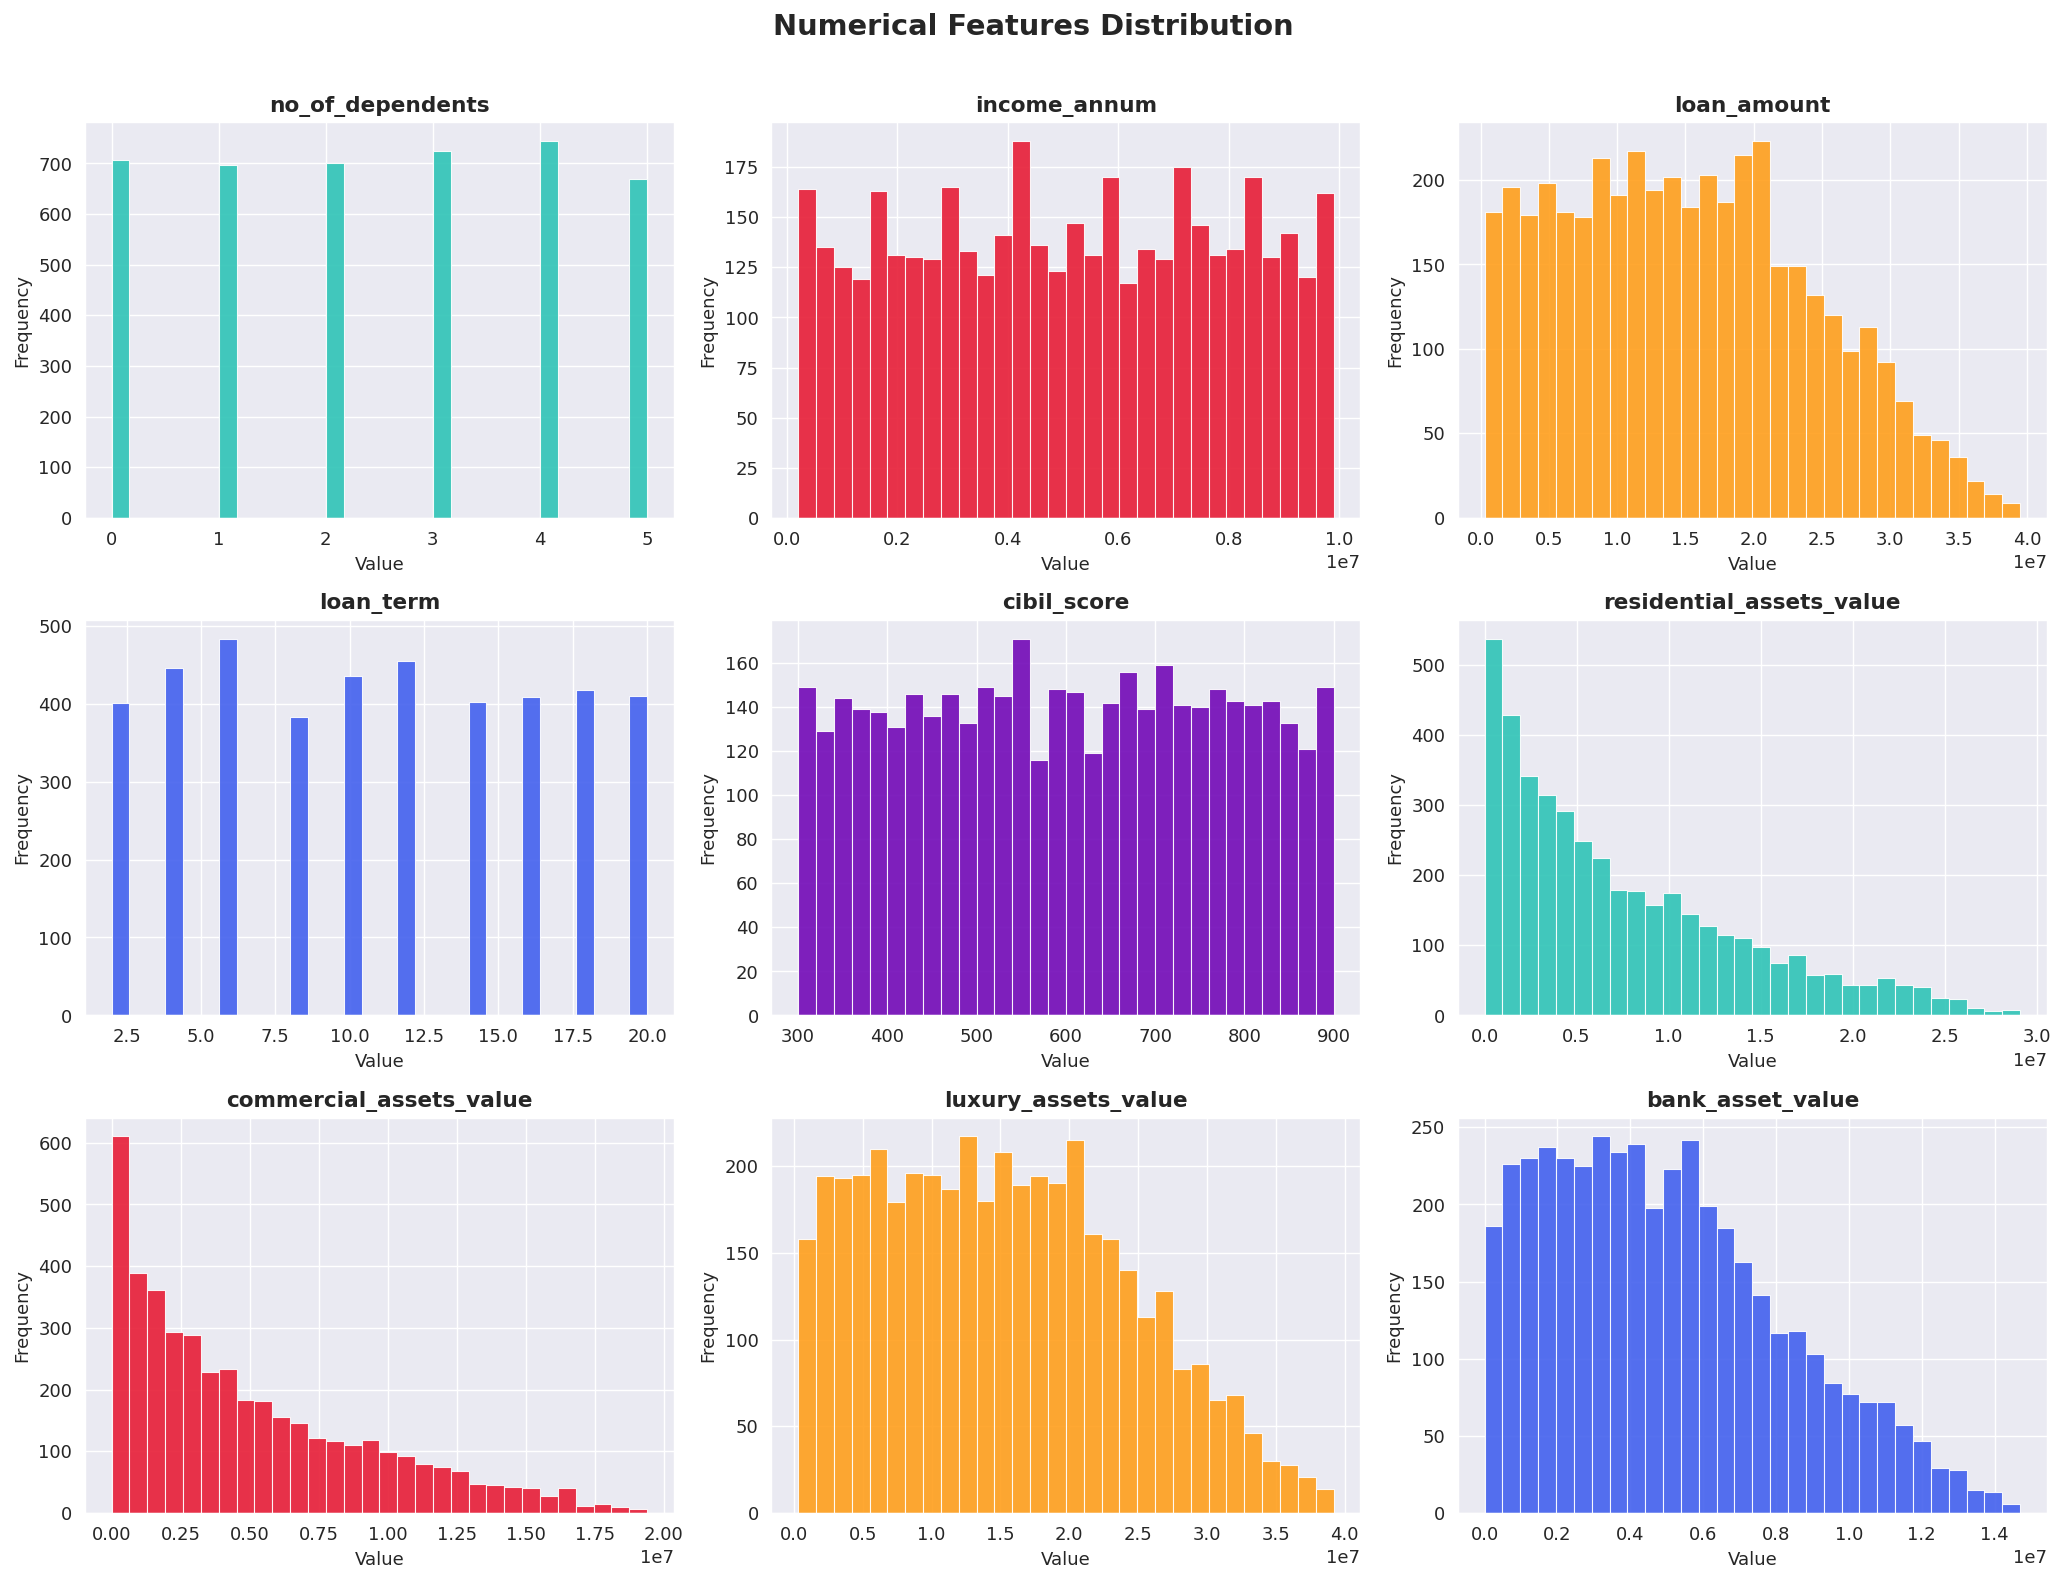

In [8]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

n = len(num_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30,
                 color=PALETTE[i % len(PALETTE)],
                 edgecolor="white", linewidth=0.6, alpha=0.9)
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Value", fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Features Distribution", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Categorical Features Distribution and Target Analysis
</h2>

Categorical Columns: ['education', 'self_employed']


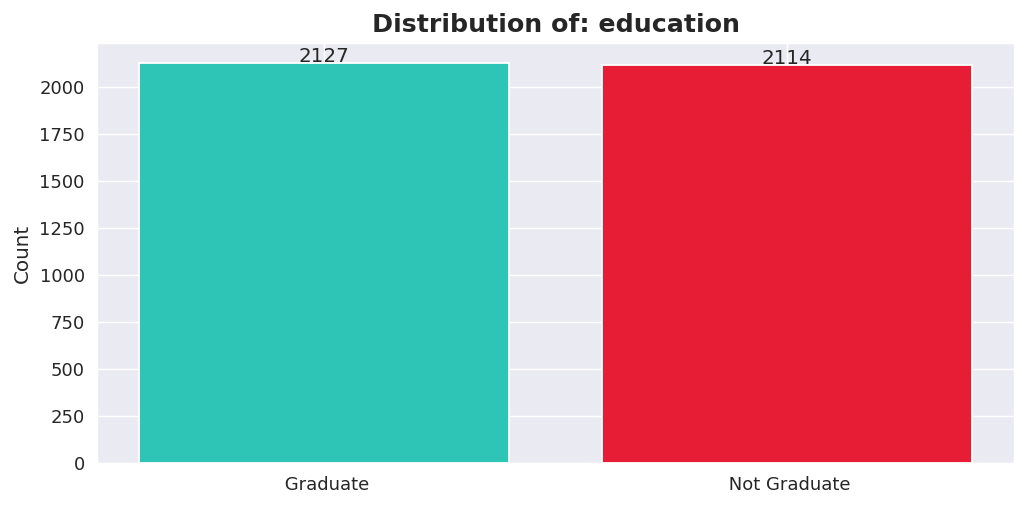

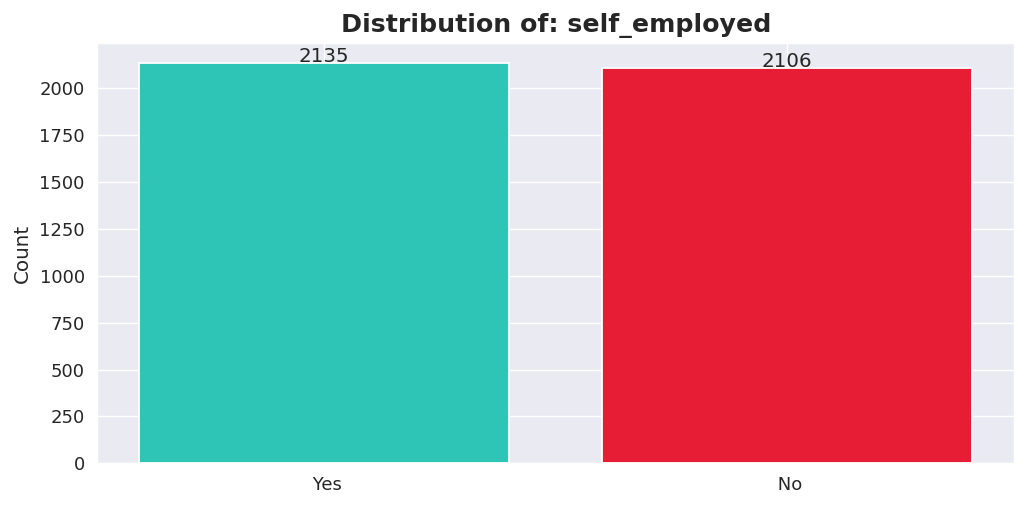

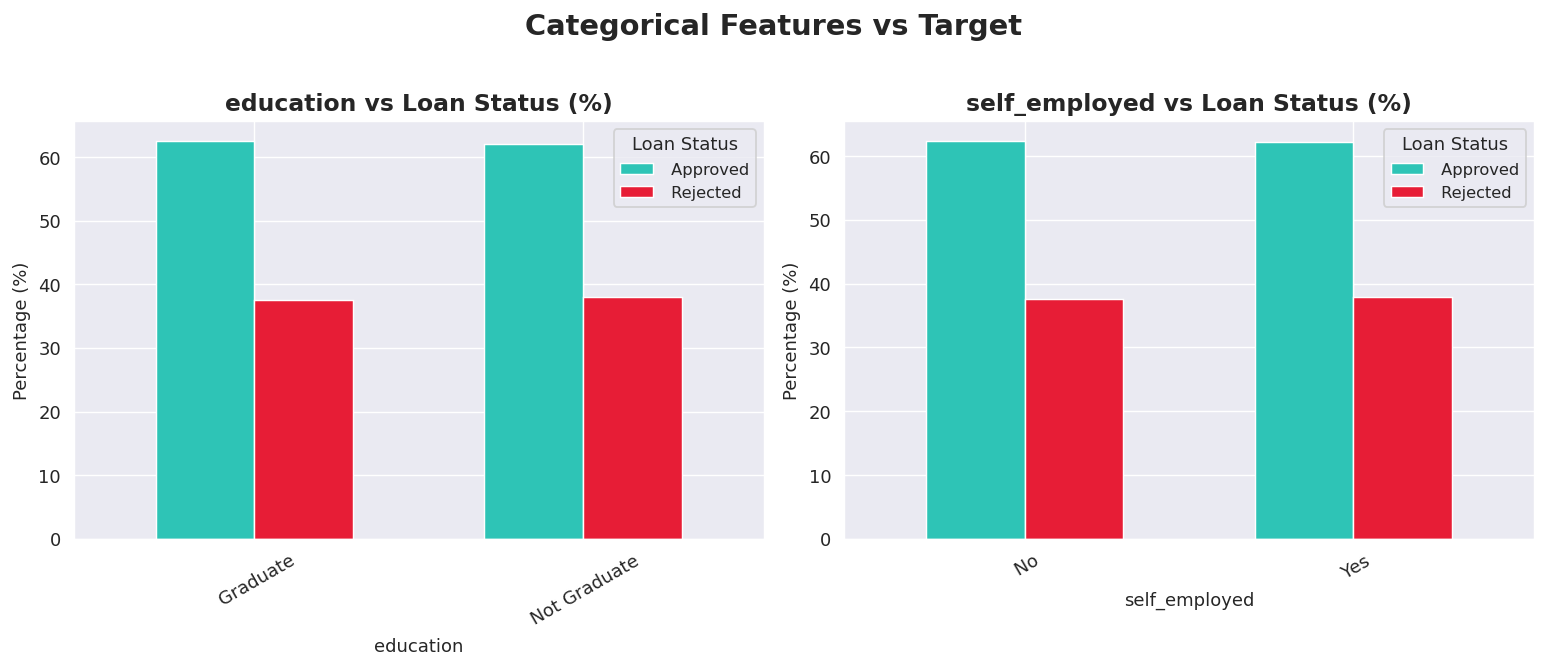

In [9]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)

print("Categorical Columns:", cat_cols)

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(counts.index, counts.values,
                  color=PALETTE[:len(counts)], edgecolor="white", linewidth=1)
    ax.set_title(f"Distribution of: {col}", fontsize=14, fontweight="bold")
    ax.set_ylabel("Count", fontsize=11)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5,
                str(int(bar.get_height())),
                ha="center", fontsize=11)
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))

if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df[target_col], normalize="index") * 100
    ct.plot(kind="bar", ax=axes[i],
            color=[PALETTE[0], PALETTE[1]],
            edgecolor="white", linewidth=0.8, width=0.6)
    axes[i].set_title(f"{col} vs Loan Status (%)", fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Percentage (%)", fontsize=10)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)
    axes[i].legend(title="Loan Status", fontsize=9)

plt.suptitle("Categorical Features vs Target", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Outlier Visualization (Boxplots)</h2>

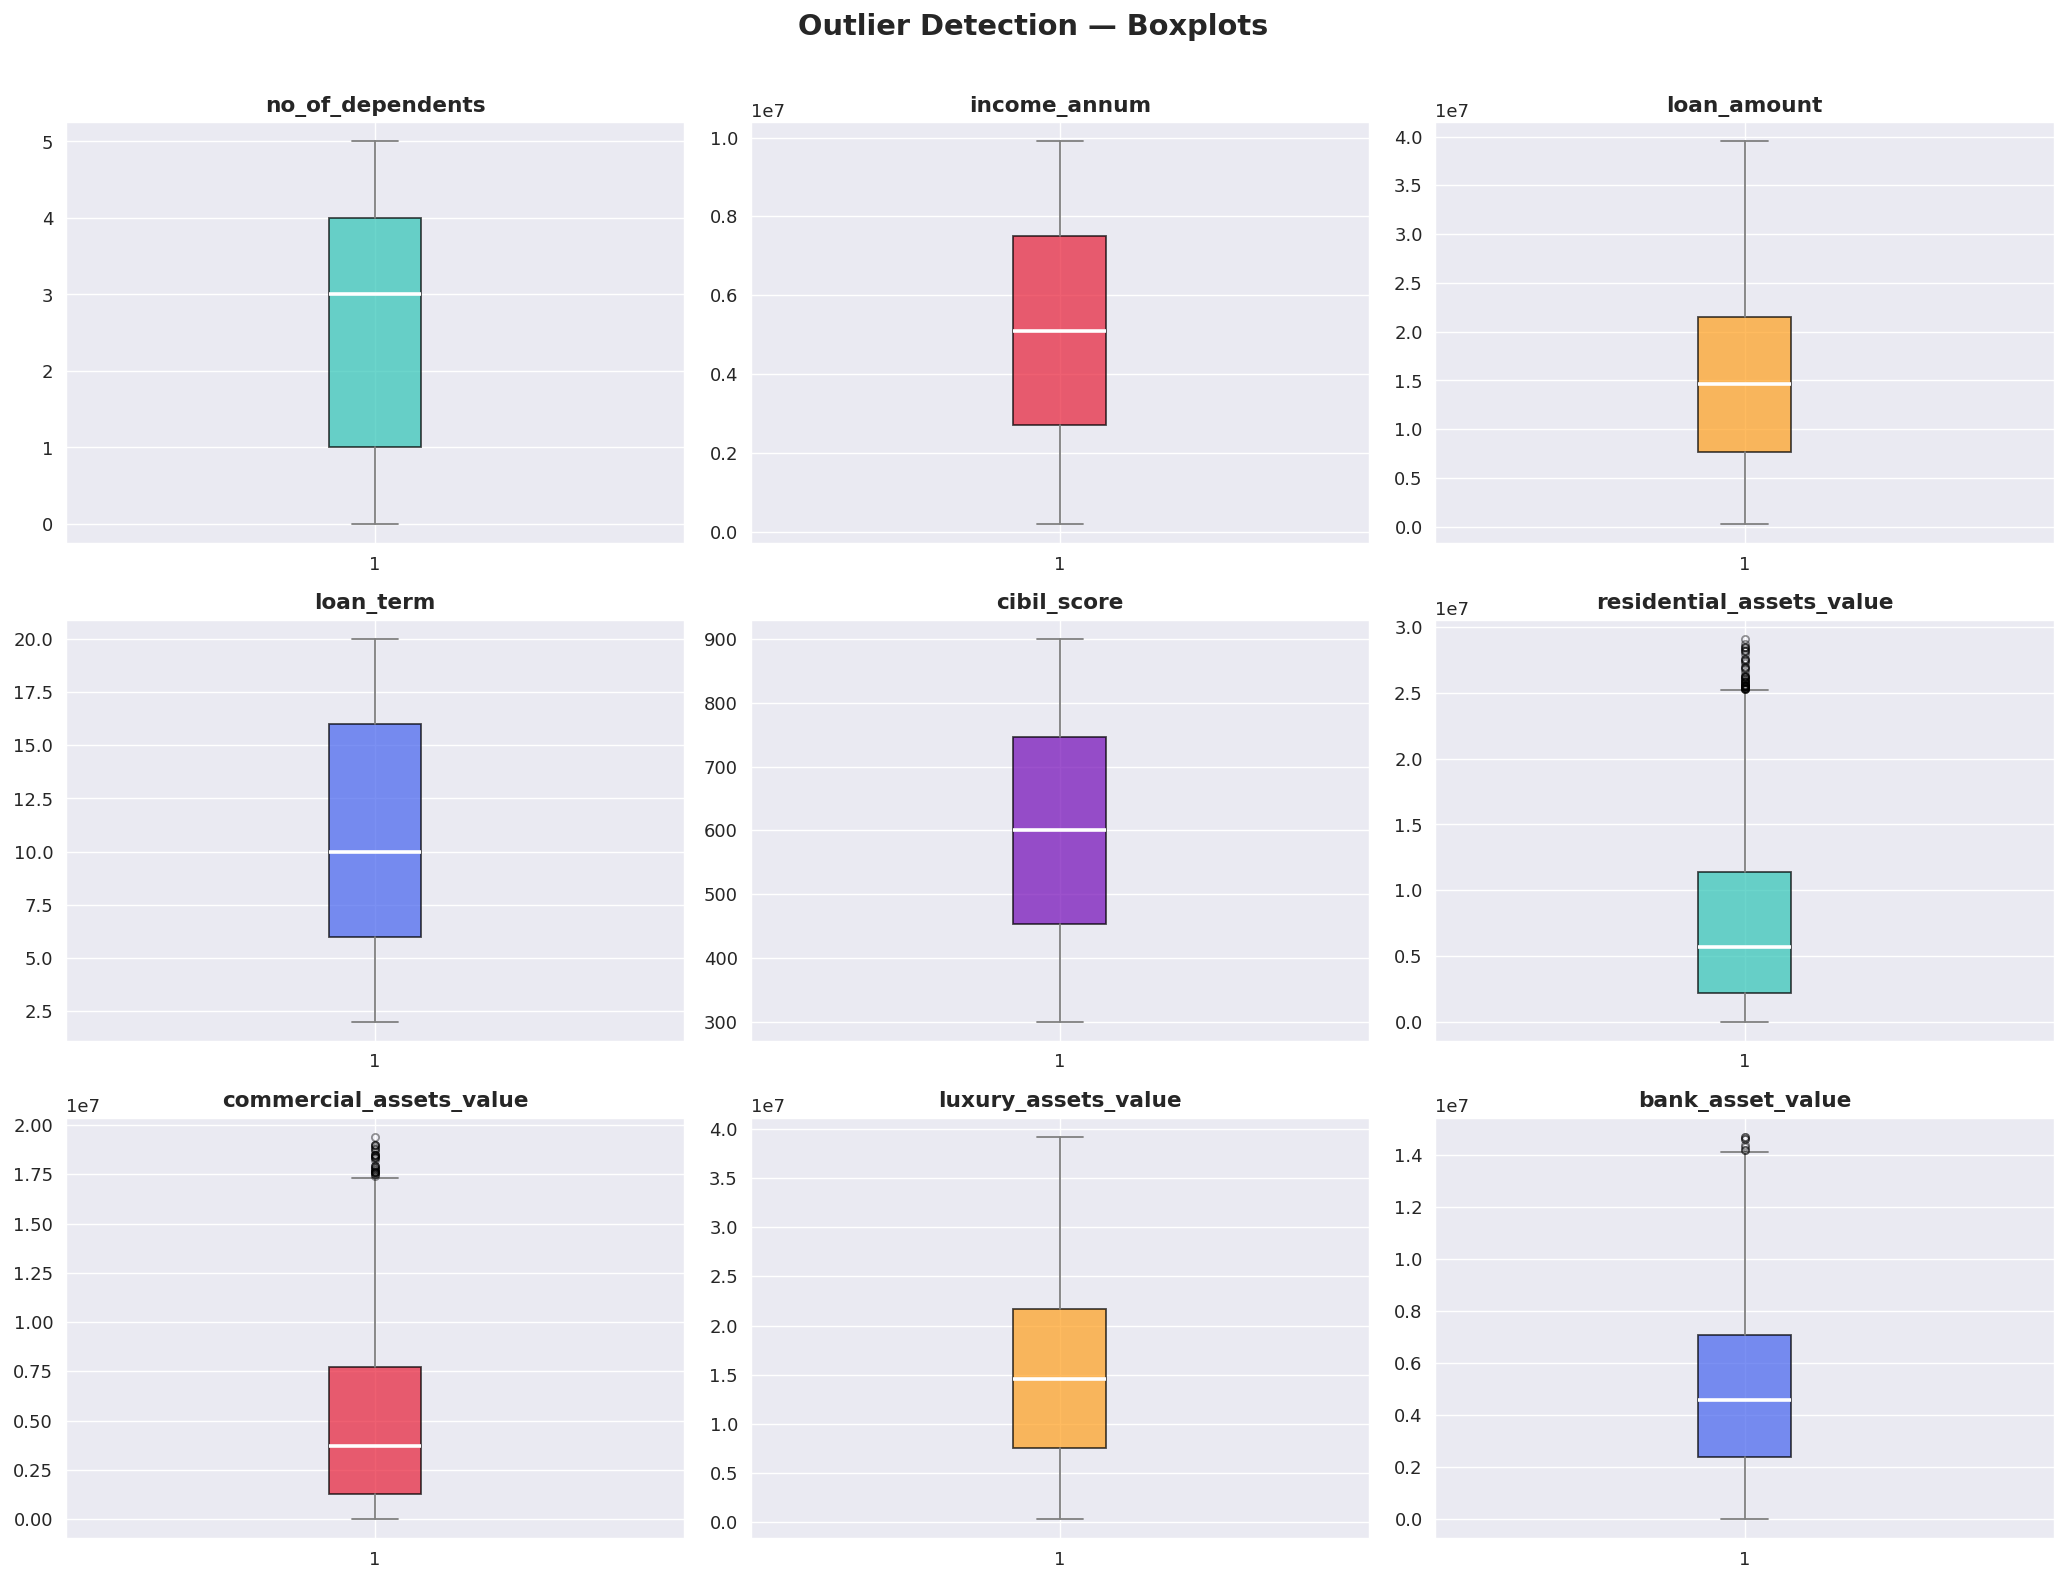

In [10]:
fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.7),
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="gray"),
                    capprops=dict(color="gray"),
                    flierprops=dict(marker="o", color=PALETTE[1], alpha=0.4, markersize=4))
    axes[i].set_title(col, fontsize=12, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outlier Detection — Boxplots", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Correlation Heatmap</h2>

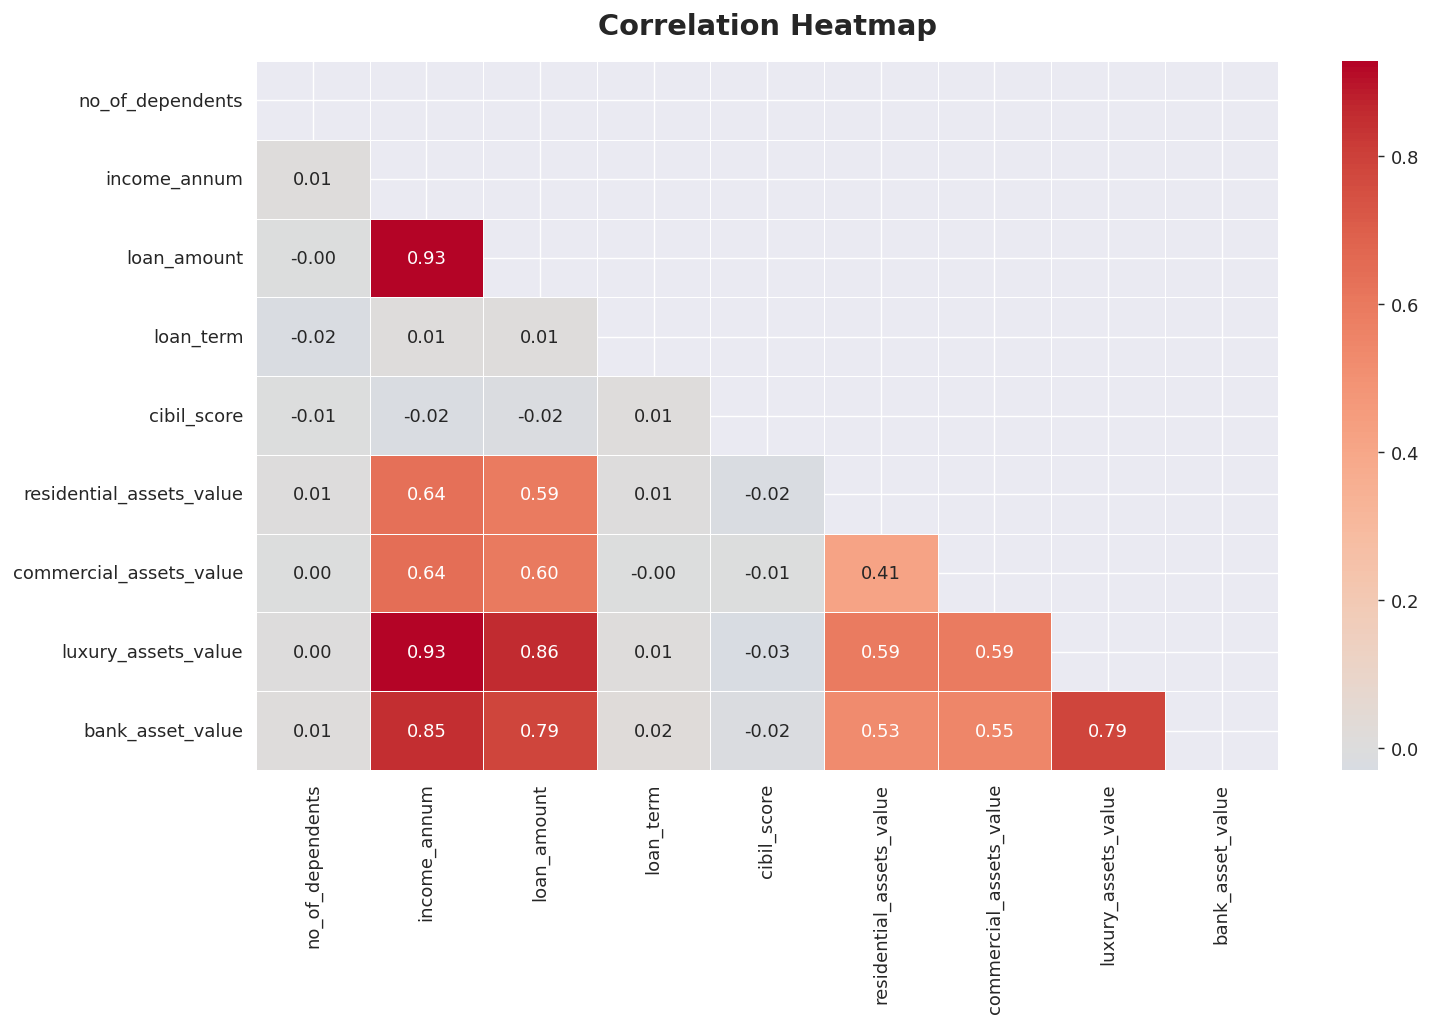

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            linecolor="white", ax=ax,
            annot_kws={"size": 10})

ax.set_title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Encode Categorical Features</h2>

In [12]:
df_model = df.copy()

le = LabelEncoder()
for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Label encoding done.")
print(df_model.dtypes)

Label encoding done.
no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
dtype: object


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Split Features and Target</h2>

In [13]:
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("Target classes:", y.unique())

Features shape: (4241, 11)
Target shape  : (4241,)
Target classes: [0 1]


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Train / Test Split</h2>

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Training set : (3392, 11)
Test set     : (849, 11)


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Feature Scaling</h2>

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Train Multiple Models</h2>

In [16]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=150, max_depth=8,
                                                    random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                        random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(model, X_train_scaled, y_train,
                              cv=StratifiedKFold(n_splits=5), scoring="accuracy")
    results[name] = {
        "model"    : model,
        "test_acc" : acc,
        "cv_mean"  : cv.mean(),
        "cv_std"   : cv.std(),
        "y_pred"   : y_pred
    }
    print(f"{name:<25} Test: {acc:.4f}  CV: {cv.mean():.4f} +/- {cv.std():.4f}")

Logistic Regression       Test: 0.9258  CV: 0.9142 +/- 0.0085
Decision Tree             Test: 0.9694  CV: 0.9746 +/- 0.0028
Random Forest             Test: 0.9776  CV: 0.9752 +/- 0.0046
Gradient Boosting         Test: 0.9859  CV: 0.9844 +/- 0.0036


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Model Comparison Chart</h2>

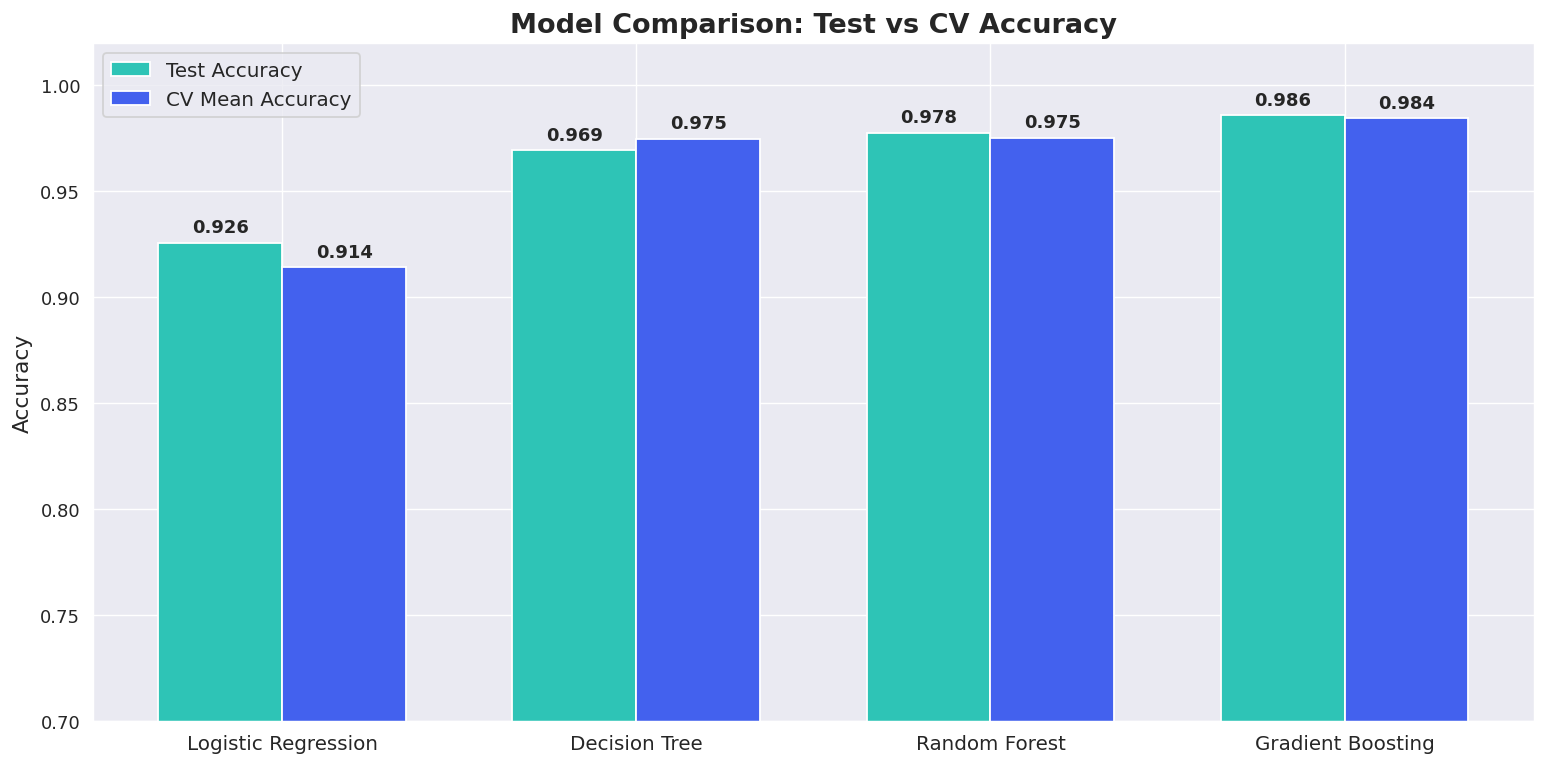

In [17]:
names    = list(results.keys())
test_acc = [results[n]["test_acc"] for n in names]
cv_mean  = [results[n]["cv_mean"]  for n in names]

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, test_acc, width, label="Test Accuracy",
               color=PALETTE[0], edgecolor="white", linewidth=1)
bars2 = ax.bar(x + width/2, cv_mean, width, label="CV Mean Accuracy",
               color=PALETTE[3], edgecolor="white", linewidth=1)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Model Comparison: Test vs CV Accuracy", fontsize=15, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Best Model</h2>

In [18]:
best_name  = max(results, key=lambda n: results[n]["cv_mean"])
best       = results[best_name]
best_model = best["model"]

print(f"Best Model : {best_name}")
print(f"Test Acc   : {best['test_acc']:.4f}")
print(f"CV Mean    : {best['cv_mean']:.4f} +/- {best['cv_std']:.4f}")

Best Model : Gradient Boosting
Test Acc   : 0.9859
CV Mean    : 0.9844 +/- 0.0036


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Classification Report</h2>

In [19]:
print("=" * 55)
print(f"CLASSIFICATION REPORT — {best_name}")
print("=" * 55)
print(classification_report(y_test, best["y_pred"]))

CLASSIFICATION REPORT — Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       528
           1       0.99      0.97      0.98       321

    accuracy                           0.99       849
   macro avg       0.99      0.98      0.98       849
weighted avg       0.99      0.99      0.99       849



<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Confusion Matrix</h2>

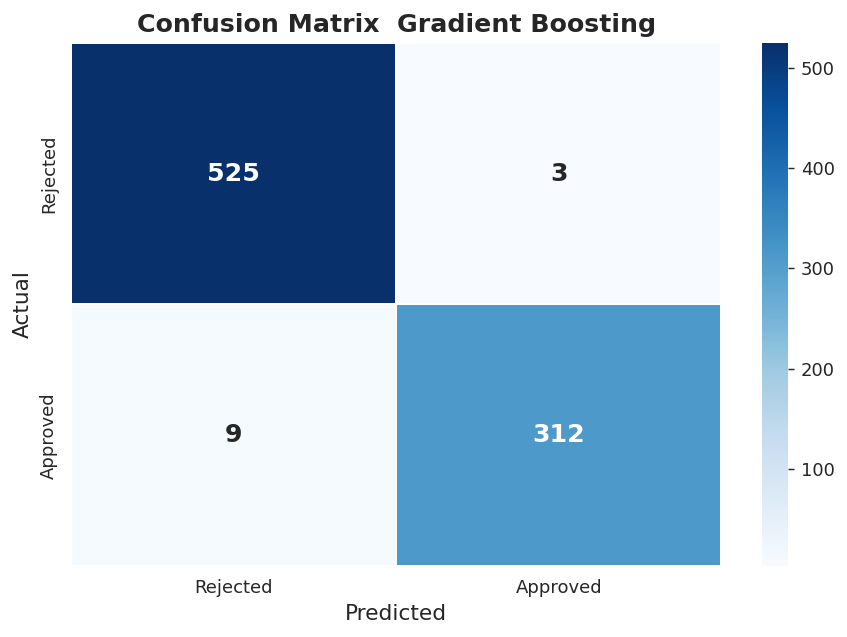

In [20]:
cm = confusion_matrix(y_test, best["y_pred"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"],
            linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"Confusion Matrix  {best_name}", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
ROC Curve</h2>

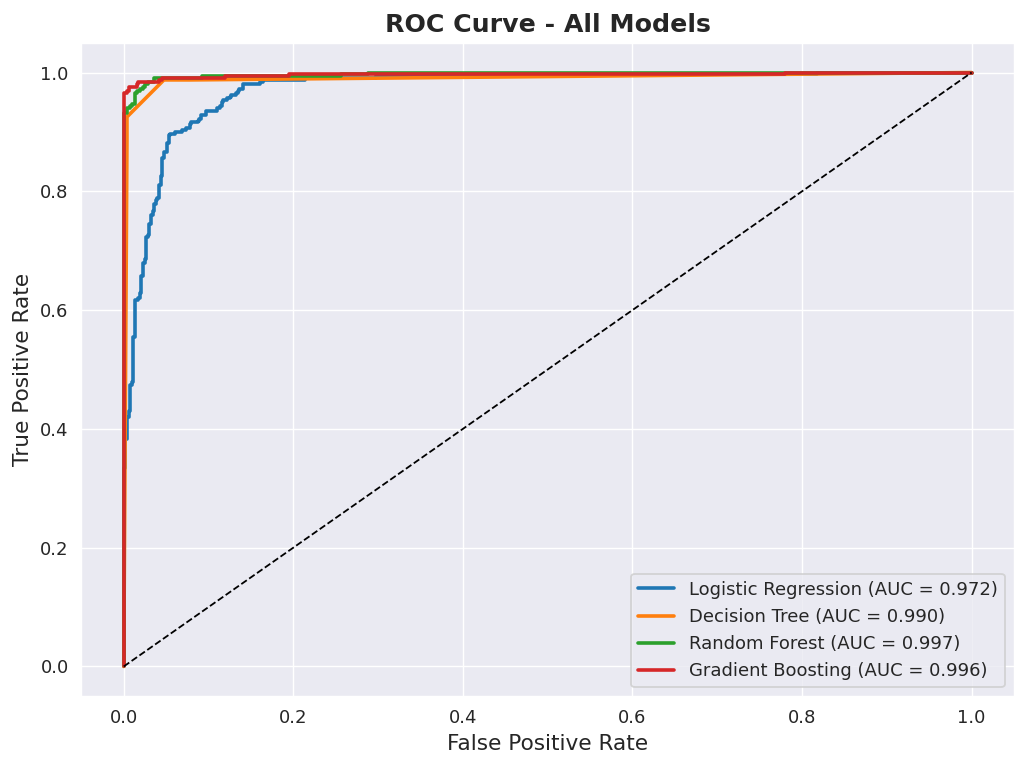

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    if hasattr(res["model"], "predict_proba"):
        y_prob = res["model"].predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve - All Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Feature Importance</h2>

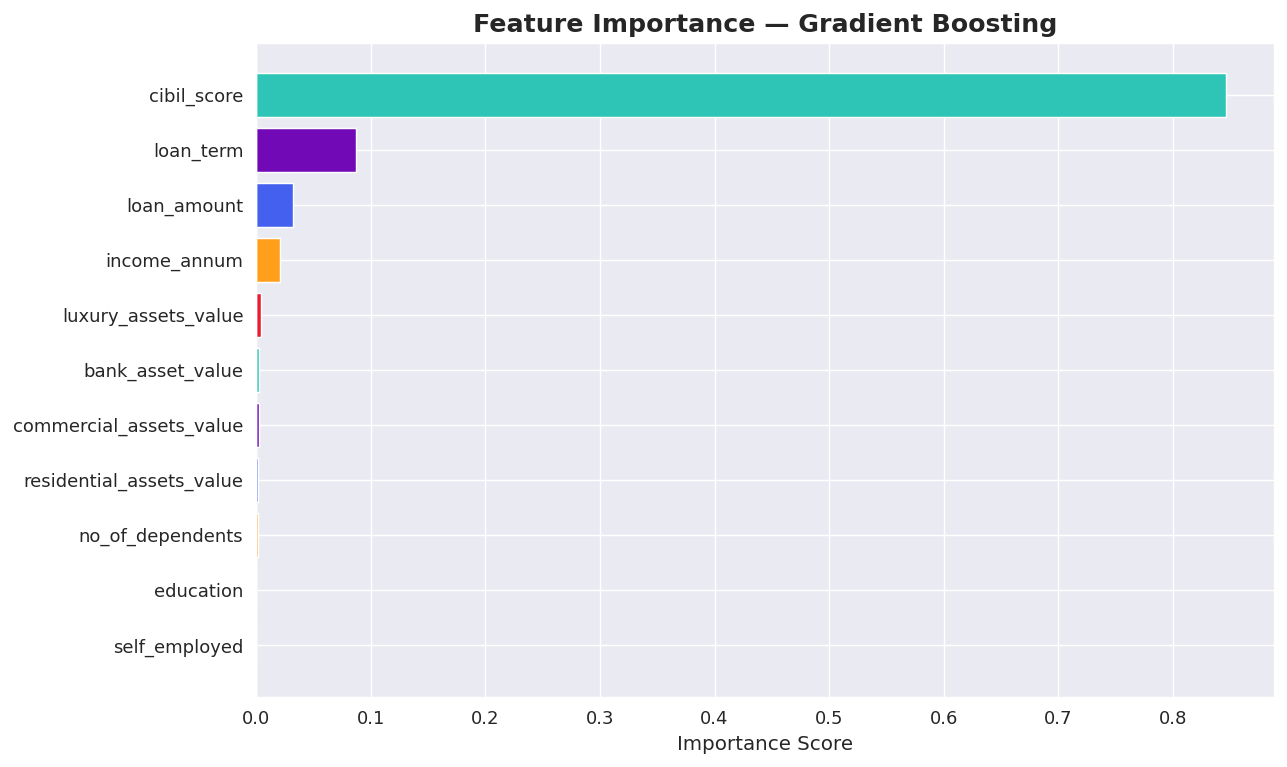

In [22]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importances.index, importances.values,
            color=[PALETTE[i % len(PALETTE)] for i in range(len(importances))],
            edgecolor="white", linewidth=0.8)
    ax.set_title(f"Feature Importance — {best_name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Importance Score", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type.")

<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Overfitting Check</h2>

In [23]:
print("=" * 55)
print("OVERFITTING CHECK")
print("=" * 55)

for name, res in results.items():
    train_acc = accuracy_score(y_train, res["model"].predict(X_train_scaled))
    test_acc  = res["test_acc"]
    gap       = train_acc - test_acc
    status    = "OVERFIT" if gap > 0.05 else "OK"
    print(f"{name:<25} Train: {train_acc:.4f}  Test: {test_acc:.4f}  Gap: {gap:.4f}  [{status}]")

OVERFITTING CHECK
Logistic Regression       Train: 0.9177  Test: 0.9258  Gap: -0.0080  [OK]
Decision Tree             Train: 0.9791  Test: 0.9694  Gap: 0.0097  [OK]
Random Forest             Train: 0.9982  Test: 0.9776  Gap: 0.0206  [OK]
Gradient Boosting         Train: 1.0000  Test: 0.9859  Gap: 0.0141  [OK]


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
 Create Sample Applicants</h2>

In [24]:
sample_applicants = pd.DataFrame({
    "no_of_dependents"        : [0, 2, 4, 1, 3],
    "education"               : [1, 1, 0, 0, 1],
    "self_employed"           : [0, 0, 1, 0, 1],
    "income_annum"            : [9000000, 5500000, 2000000, 7500000, 3200000],
    "loan_amount"             : [5000000, 12000000, 20000000, 8000000, 15000000],
    "loan_term"               : [8, 12, 20, 6, 16],
    "cibil_score"             : [800, 650, 400, 750, 500],
    "residential_assets_value": [15000000, 8000000, 1000000, 12000000, 3000000],
    "commercial_assets_value" : [10000000, 4000000, 500000, 7000000, 1000000],
    "luxury_assets_value"     : [20000000, 9000000, 2000000, 14000000, 4000000],
    "bank_asset_value"        : [8000000, 3000000, 500000, 6000000, 1500000]
})

applicant_names = [
    "Applicant A - High Income",
    "Applicant B - Average Profile",
    "Applicant C - Low Income",
    "Applicant D - Good Credit",
    "Applicant E - High Risk"
]

print("Sample applicants created.")
sample_applicants

Sample applicants created.


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,0,1,0,9000000,5000000,8,800,15000000,10000000,20000000,8000000
1,2,1,0,5500000,12000000,12,650,8000000,4000000,9000000,3000000
2,4,0,1,2000000,20000000,20,400,1000000,500000,2000000,500000
3,1,0,0,7500000,8000000,6,750,12000000,7000000,14000000,6000000
4,3,1,1,3200000,15000000,16,500,3000000,1000000,4000000,1500000


<h2 style="
text-align:center;
color:#0d47a1;
font-weight:bold;
font-size:30px;
text-shadow:2px 2px 10px rgba(13,71,161,0.4);
letter-spacing:1px;">
Loan Approval Prediction Results
</h2>

In [25]:
sample_scaled   = scaler.transform(sample_applicants)
predictions     = best_model.predict(sample_scaled)
probabilities   = best_model.predict_proba(sample_scaled)

prob_approved   = [f"{p[1]*100:.1f}%" for p in probabilities]
prob_rejected   = [f"{p[0]*100:.1f}%" for p in probabilities]
decision        = ["APPROVED" if p == 1 else "REJECTED" for p in predictions]

results_df = pd.DataFrame({
    "Applicant"        : applicant_names,
    "Annual Income"    : [f"{v:,}" for v in sample_applicants["income_annum"]],
    "Loan Amount"      : [f"{v:,}" for v in sample_applicants["loan_amount"]],
    "CIBIL Score"      : sample_applicants["cibil_score"].values,
    "Loan Term (yrs)"  : sample_applicants["loan_term"].values,
    "Prob Approved"    : prob_approved,
    "Prob Rejected"    : prob_rejected,
    "Decision"         : decision
})

def color_decision(val):
    if val == "APPROVED":
        return "background-color: #2EC4B6; color: white; font-weight: bold; text-align: center"
    else:
        return "background-color: #E71D36; color: white; font-weight: bold; text-align: center"

def color_cibil(val):
    if val >= 750:
        return "background-color: #c8f7c5; color: #1a7a16; font-weight: bold"
    elif val >= 600:
        return "background-color: #fff3cd; color: #856404; font-weight: bold"
    else:
        return "background-color: #ffd6d6; color: #b30000; font-weight: bold"

styled = (results_df.style
          .applymap(color_decision, subset=["Decision"])
          .applymap(color_cibil,    subset=["CIBIL Score"])
          .set_table_styles([
              {"selector": "thead th",
               "props": [("background-color", "#4361EE"),
                         ("color", "white"),
                         ("font-size", "13px"),
                         ("text-align", "center"),
                         ("padding", "10px")]},
              {"selector": "tbody td",
               "props": [("text-align", "center"),
                         ("padding", "9px"),
                         ("font-size", "12px")]},
              {"selector": "tbody tr:nth-child(even)",
               "props": [("background-color", "#f5f5f5")]},
          ])
          .set_caption("Loan Approval Prediction Results")
          .hide(axis="index"))

styled

Applicant,Annual Income,Loan Amount,CIBIL Score,Loan Term (yrs),Prob Approved,Prob Rejected,Decision
Applicant A - High Income,"9,000,000","5,000,000",800,8,0.0%,100.0%,REJECTED
Applicant B - Average Profile,"5,500,000","12,000,000",650,12,0.0%,100.0%,REJECTED
Applicant C - Low Income,"2,000,000","20,000,000",400,20,100.0%,0.0%,APPROVED
Applicant D - Good Credit,"7,500,000","8,000,000",750,6,0.0%,100.0%,REJECTED
Applicant E - High Risk,"3,200,000","15,000,000",500,16,99.7%,0.3%,APPROVED
